In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(cowplot)
library(immunarch)
library(ggbreak)
library(PNWColors)

Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.2 but the current
version is 1.7.3; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Loading required package: dtplyr

Loading required package: data.table

Warning message:
“package ‘data.table’ was built under R version 4.4.3”

Attaching package: ‘data.table’


The following objects are masked from ‘package:dp

In [2]:
so <- readRDS('seurat_objects/integrated_so.rds')

# Clone Type Analysis

In [3]:
clone_type_df_total <- so@meta.data  %>%
    filter(L1 == 'T cell') %>%
    group_by(tech, clone_type) %>%
    summarise(count = n()) %>%
    group_by(tech) %>%
    mutate(prop = count / sum(count)) %>%
    filter(clone_type != 'No clone')
clone_type_df_total

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by tech and clone_type.
ℹ Output is grouped by tech.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(tech, clone_type))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


tech,clone_type,count,prop
<chr>,<chr>,<int>,<dbl>
10x_5prime,TRA,218,0.02040052
10x_5prime,TRA;TRB,9604,0.89874602
10x_5prime,TRB,456,0.04267266
REFLEX,TRA,7346,0.07605578
REFLEX,TRA;TRB,47868,0.49559465
REFLEX,TRB,27861,0.28845497


In [5]:
0.49559465+0.07605578
0.49559465+0.28845497

[1] 0.5716504

[1] 0.7840496

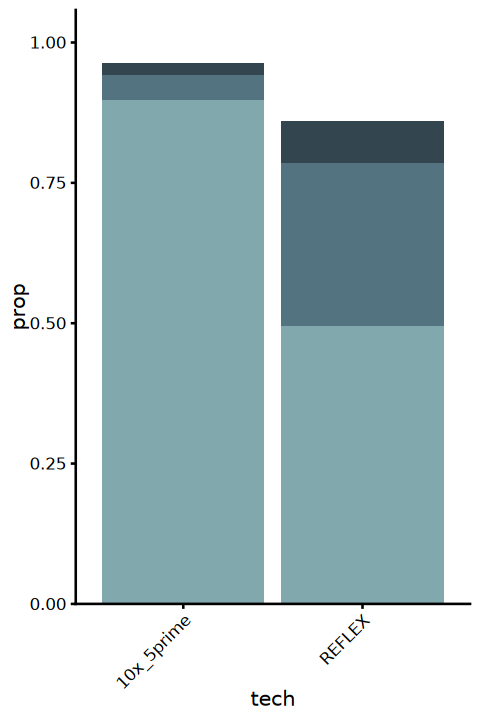

In [4]:
options(repr.plot.width = 4, repr.plot.height = 6)
clone_type_df_total %>%
    mutate(clone_type = factor(clone_type, levels = c('TRA','TRB','TRA;TRB'))) %>%
    ggplot(aes(x = tech, y = prop, fill = clone_type)) +
      geom_bar(stat = 'identity') +
      theme_classic(base_size = 12) +
      RotatedAxis() + scale_fill_manual(values = c('#33454e','#537380','#81a9ad')) +
      theme(legend.position = 'none') +
      scale_y_continuous(expand = expansion(mult = c(0, 0.1)))

In [5]:
total_t_prop_plot <- clone_type_df_total %>%
    mutate(clone_type = factor(clone_type, levels = c('TRA','TRB','TRA;TRB'))) %>%
    ggplot(aes(x = tech, y = prop, fill = clone_type)) +
      geom_bar(stat = 'identity') +
      theme_classic(base_size = 12) +
      RotatedAxis() + scale_fill_manual(values = c('#33454e','#537380','#81a9ad')) +
      theme(legend.position = 'none') +
      scale_y_continuous(expand = expansion(mult = c(0, 0.1)))

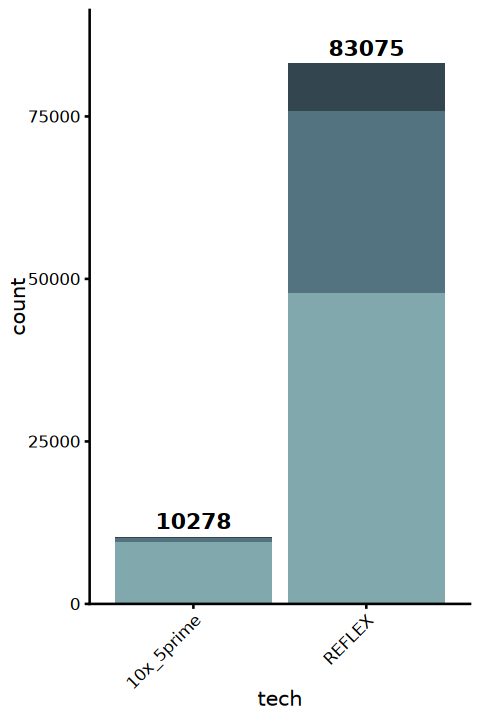

In [6]:
options(repr.plot.width = 4, repr.plot.height = 6)
clone_type_df_total %>%
    mutate(clone_type = factor(clone_type, levels = c('TRA','TRB','TRA;TRB'))) %>%
    ggplot(aes(x = tech, y = count, fill = clone_type)) +
      geom_bar(stat = 'identity') +
      stat_summary(
        fun = sum, 
        aes(label = after_stat(y), group = tech), 
        geom = "text", 
        vjust = -0.5,      
        size = 4.5,        
        fontface = "bold", 
        inherit.aes = TRUE
      ) +
      theme_classic(base_size = 12) +
      RotatedAxis() + scale_fill_manual(values = c('#33454e','#537380','#81a9ad')) +
      theme(legend.position = 'none') +
      scale_y_continuous(expand = expansion(mult = c(0, 0.1)))

In [7]:
absolute_total_t_plot <- clone_type_df_total %>%
    mutate(clone_type = factor(clone_type, levels = c('TRA','TRB','TRA;TRB'))) %>%
    ggplot(aes(x = tech, y = count, fill = clone_type)) +
      geom_bar(stat = 'identity') +
      stat_summary(
        fun = sum, 
        aes(label = after_stat(y), group = tech), 
        geom = "text", 
        vjust = -0.5,      
        size = 4.5,        
        fontface = "bold", 
        inherit.aes = TRUE
      ) +
      theme_classic(base_size = 12) +
      RotatedAxis() + scale_fill_manual(values = c('#33454e','#537380','#81a9ad')) +
      theme(legend.position = 'none') +
      scale_y_continuous(expand = expansion(mult = c(0, 0.1)))

In [8]:
clone_type_df <- so@meta.data  %>%
    group_by(tech, L2, clone_type) %>%
    summarise(count = n()) %>%
    group_by(tech, L2) %>%
    mutate(prop = count / sum(count)) %>%
    filter(clone_type != 'No clone') %>%
    filter(L2 %in% c('Naive CD4 T cell','Memory CD4 T cell','Treg','Naive CD8 T cell','Memory CD8 T cell','CD8aa','DN T cell','MAIT','Proliferating T cell','gdT'))

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by tech, L2, and clone_type.
ℹ Output is grouped by tech and L2.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(tech, L2, clone_type))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


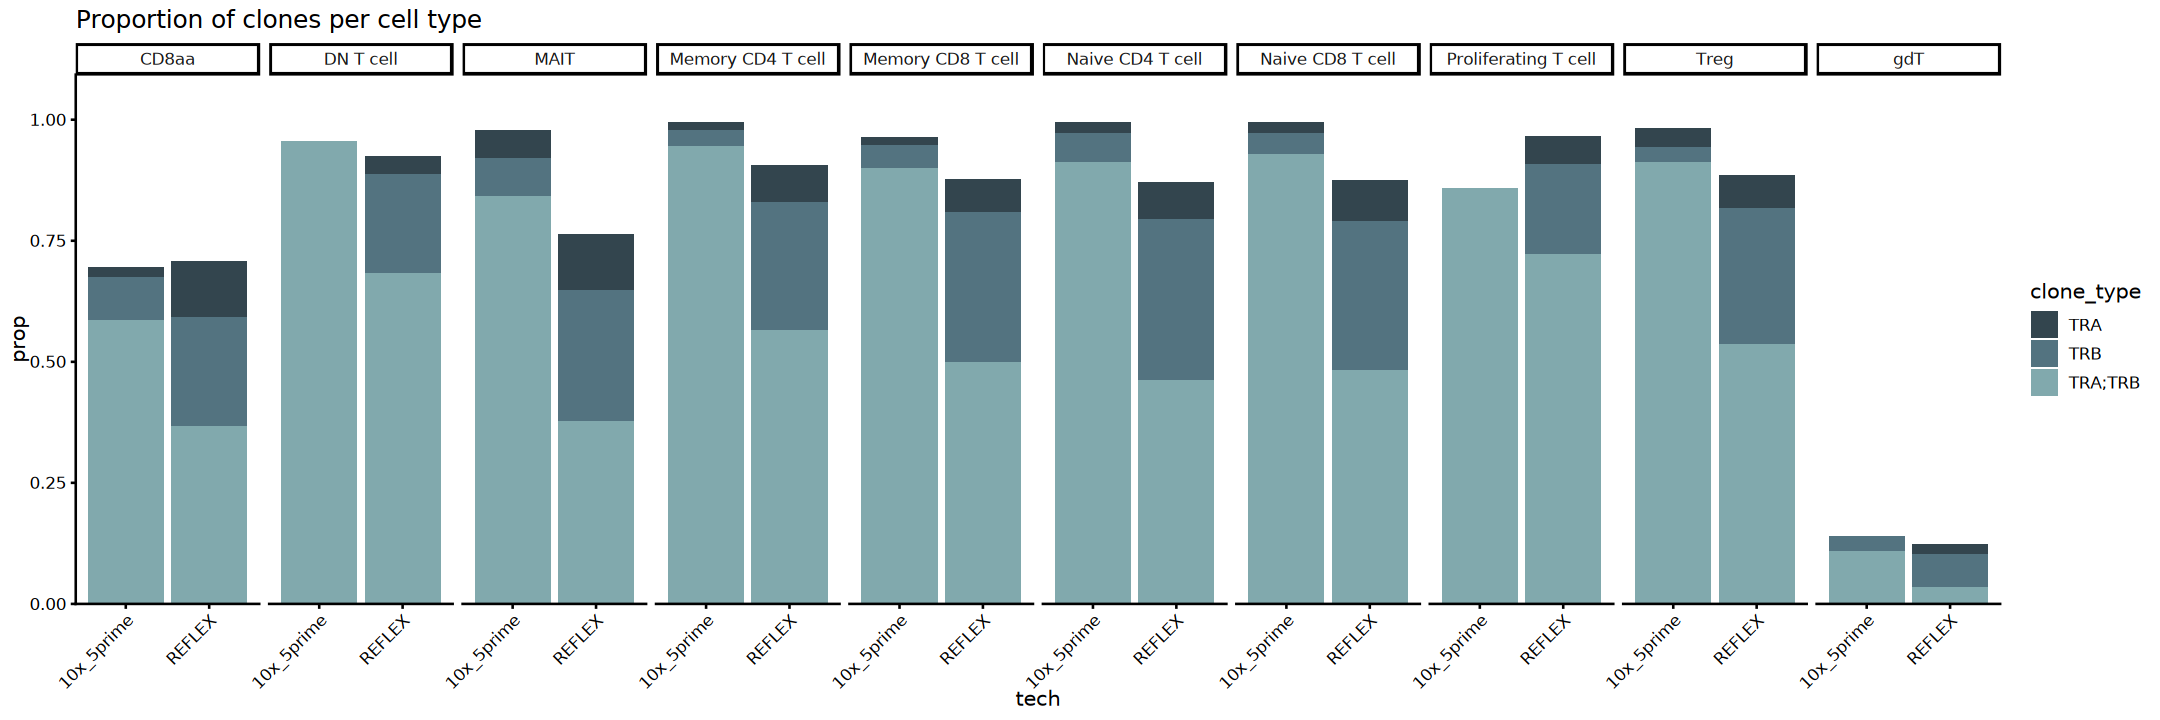

In [9]:
options(repr.plot.width = 18, repr.plot.height = 6)
clone_type_df %>%
    mutate(clone_type = factor(clone_type, levels = c('TRA','TRB','TRA;TRB'))) %>%
    ggplot(aes(x = tech, y = prop, fill = clone_type)) +
      geom_bar(stat = 'identity') +
      # geom_text(
      #   aes(label = round(prop, 2)),                # Rounds to 3 decimal places
      #   position = position_dodge(width = 0.9),     # Must match bar dodge width
      #   vjust = -0.5,                               # 'Vertical Justification' - moves text above bar
      #   size = 5                                    # Adjust text size as needed
      # ) +
      theme_classic(base_size = 12) +
      RotatedAxis() + scale_fill_manual(values = c('#33454e','#537380','#81a9ad')) +
      ggtitle('Proportion of clones per cell type') +
      # Optional: expand the y-axis slightly so labels don't get cut off at the top
      scale_y_continuous(expand = expansion(mult = c(0, 0.1))) + facet_grid(cols = vars(L2))

In [10]:
prop_clone_celltype_plot <- clone_type_df %>%
    mutate(clone_type = factor(clone_type, levels = c('TRA','TRB','TRA;TRB'))) %>%
    ggplot(aes(x = tech, y = prop, fill = clone_type)) +
      geom_bar(stat = 'identity') +
      # geom_text(
      #   aes(label = round(prop, 2)),                # Rounds to 3 decimal places
      #   position = position_dodge(width = 0.9),     # Must match bar dodge width
      #   vjust = -0.5,                               # 'Vertical Justification' - moves text above bar
      #   size = 5                                    # Adjust text size as needed
      # ) +
      theme_classic(base_size = 12) +
      RotatedAxis() + scale_fill_manual(values = c('#33454e','#537380','#81a9ad')) +
      ggtitle('Proportion of clones per cell type') +
      # Optional: expand the y-axis slightly so labels don't get cut off at the top
      scale_y_continuous(expand = expansion(mult = c(0, 0.1))) + facet_grid(cols = vars(L2))

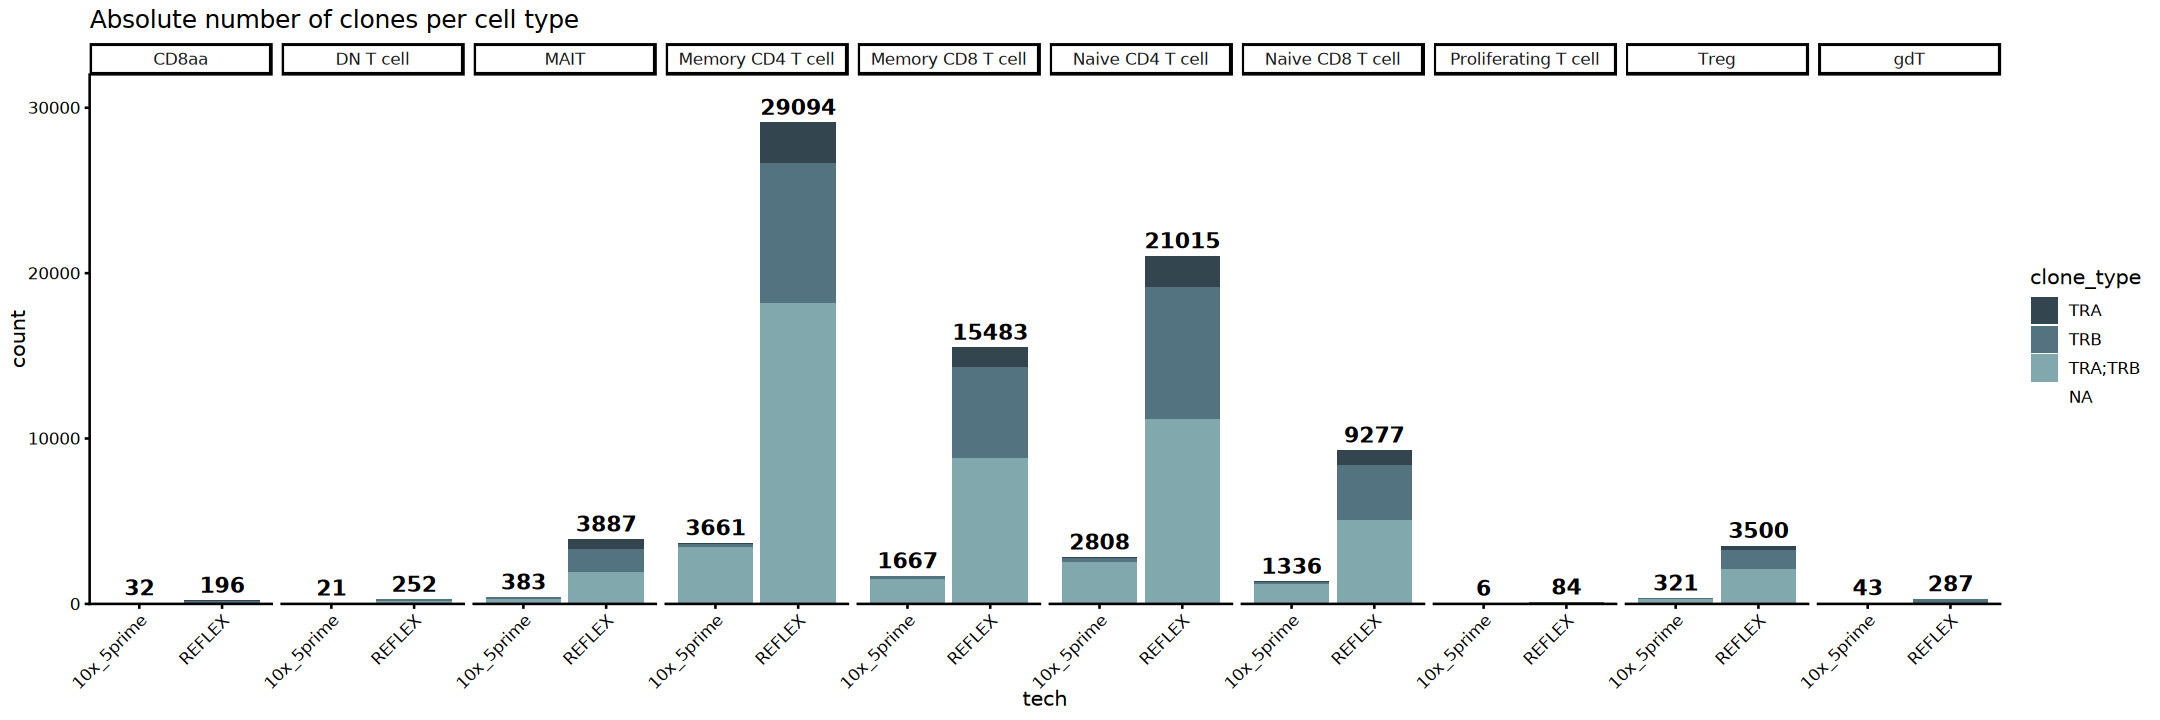

In [11]:
options(repr.plot.width = 18, repr.plot.height = 6)
clone_type_df %>%
    mutate(clone_type = factor(clone_type, levels = c('TRA','TRB','TRA;TRB'))) %>%
    ggplot(aes(x = tech, y = count, fill = clone_type)) +
      geom_bar(stat = 'identity') +
      stat_summary(
        fun = sum, 
        aes(label = after_stat(y), group = tech), 
        geom = "text", 
        vjust = -0.5,      
        size = 4.5,        
        fontface = "bold", 
        inherit.aes = TRUE
      ) +
      theme_classic(base_size = 12) +
      RotatedAxis() + scale_fill_manual(values = c('#33454e','#537380','#81a9ad')) +
      ggtitle('Absolute number of clones per cell type') +
      # Optional: expand the y-axis slightly so labels don't get cut off at the top
      scale_y_continuous(expand = expansion(mult = c(0, 0.1))) + facet_grid(cols = vars(L2))

In [12]:
absolute_celltype_plot <- clone_type_df %>%
    mutate(clone_type = factor(clone_type, levels = c('TRA','TRB','TRA;TRB'))) %>%
    ggplot(aes(x = tech, y = count, fill = clone_type)) +
      geom_bar(stat = 'identity') +
      stat_summary(
        fun = sum, 
        aes(label = after_stat(y), group = tech), 
        geom = "text", 
        vjust = -0.5,      
        size = 4.5,        
        fontface = "bold", 
        inherit.aes = TRUE
      ) +
      theme_classic(base_size = 12) +
      RotatedAxis() + scale_fill_manual(values = c('#33454e','#537380','#81a9ad')) +
      ggtitle('Absolute number of clones per cell type') +
      # Optional: expand the y-axis slightly so labels don't get cut off at the top
      scale_y_continuous(expand = expansion(mult = c(0, 0.1))) + facet_grid(cols = vars(L2))

## Final Plot

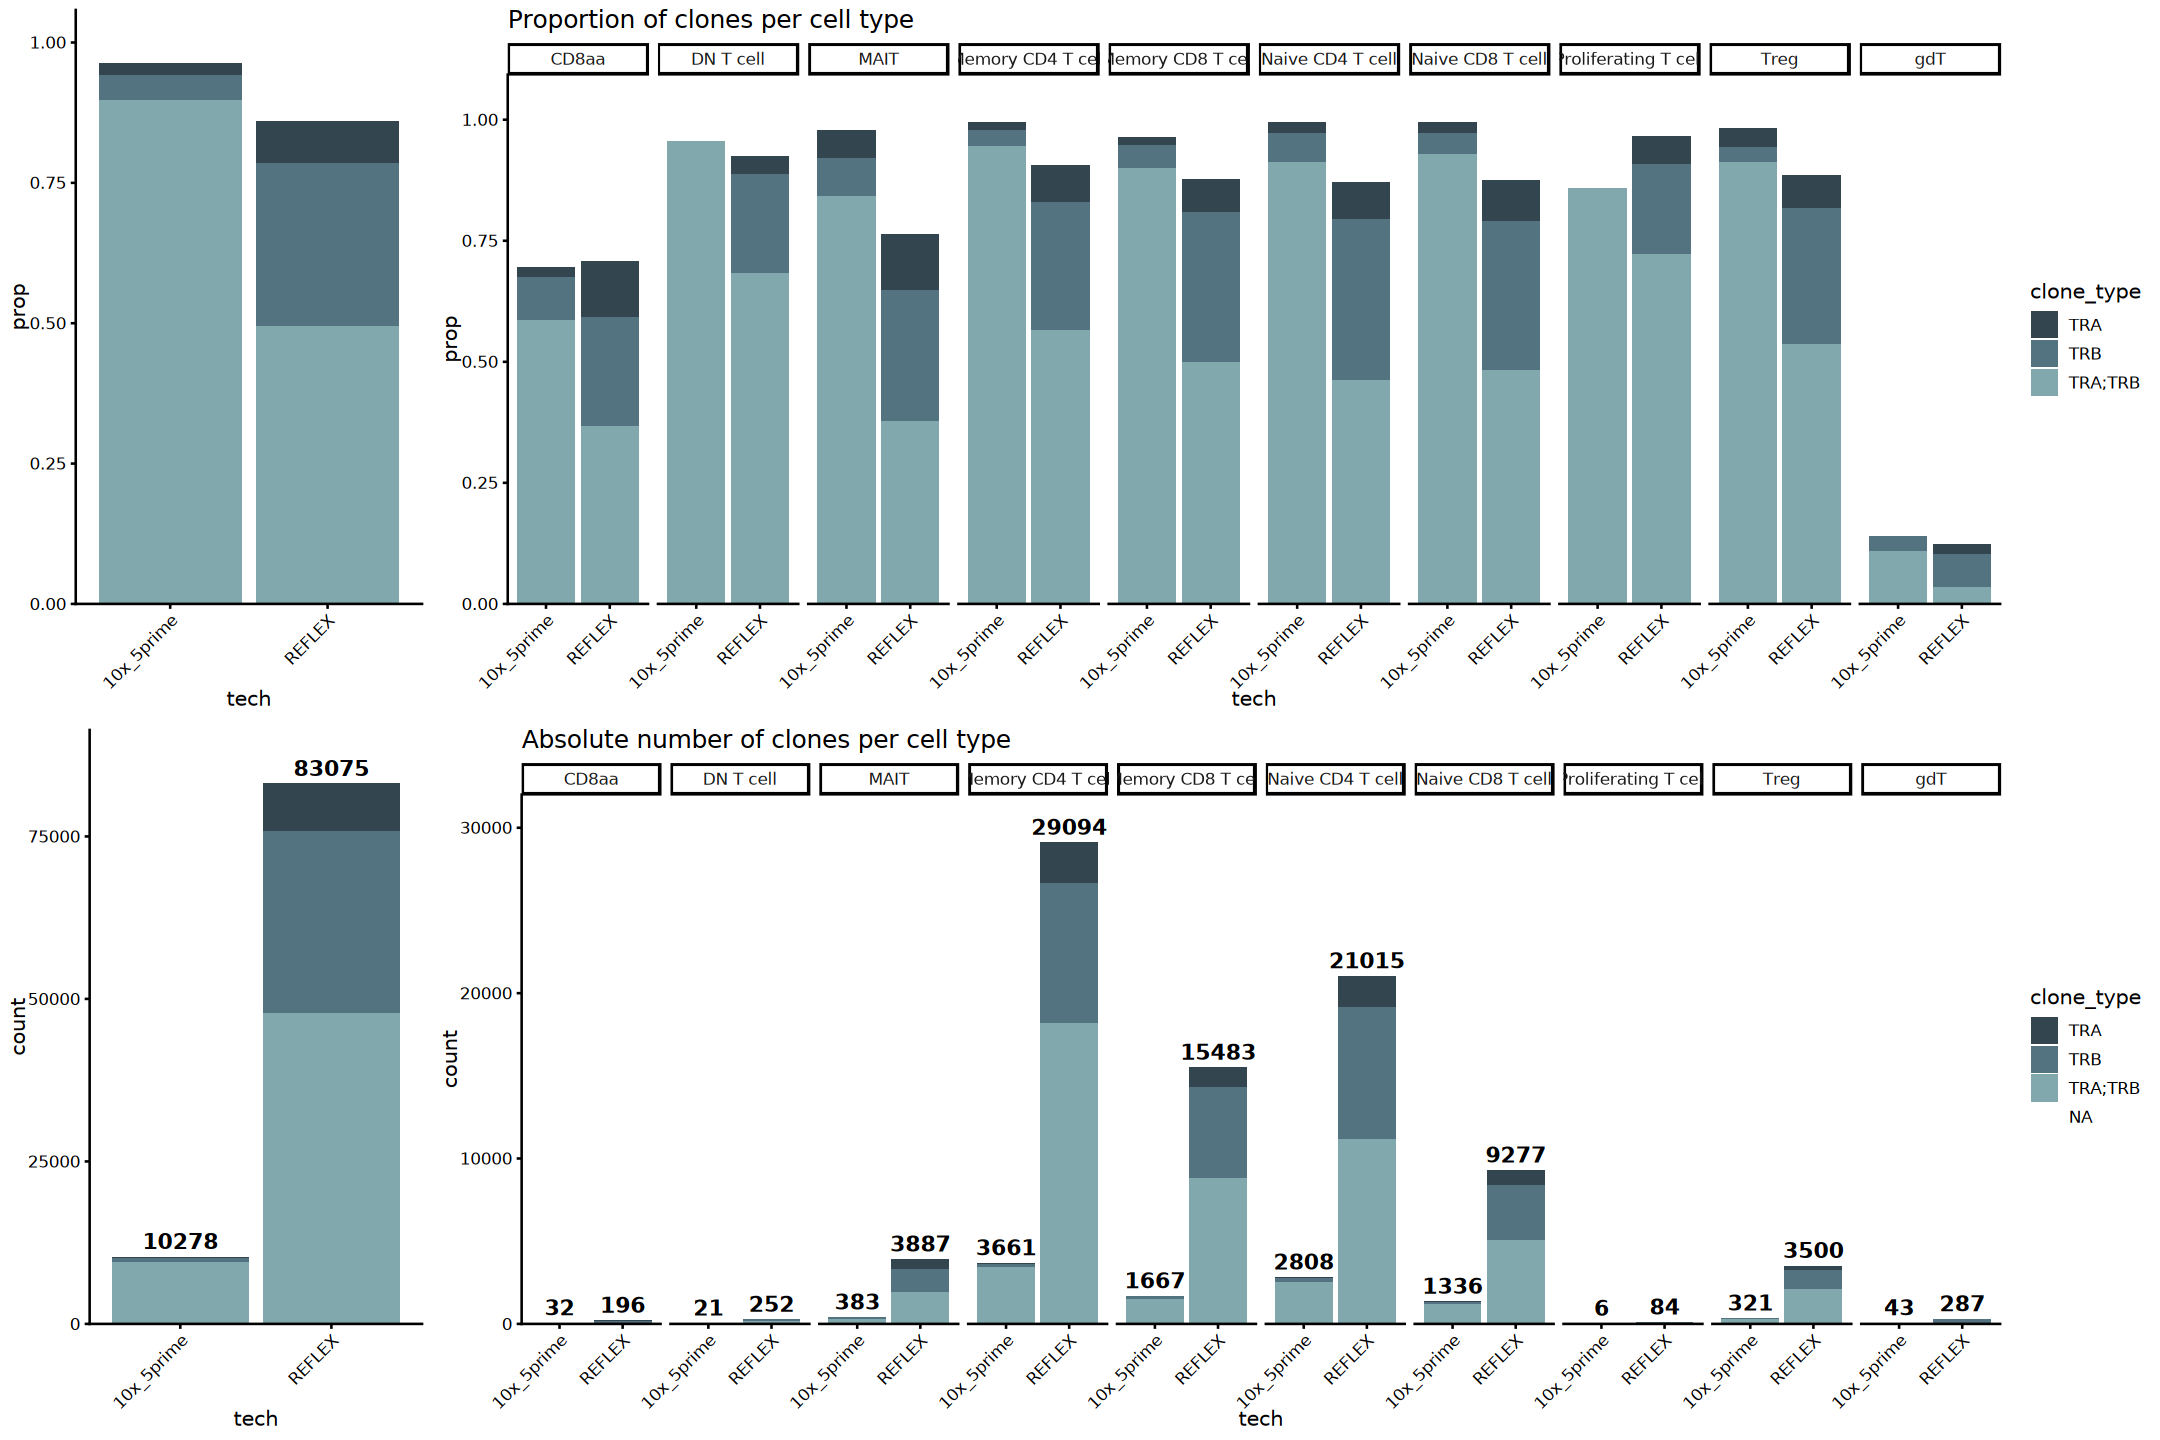

In [13]:
options(repr.plot.width = 18, repr.plot.height = 12)
cowplot::plot_grid(total_t_prop_plot, prop_clone_celltype_plot, absolute_total_t_plot, absolute_celltype_plot, ncol=2, rel_widths = c(0.2,0.8))

In [14]:
# Open the PDF graphics device
pdf("plots/Fig1d_clone_type_plots.pdf", width = 18, height = 12) # You can specify width and height in inches

# Create your plot
cowplot::plot_grid(total_t_prop_plot, prop_clone_celltype_plot, absolute_total_t_plot, absolute_celltype_plot, ncol=2, rel_widths = c(0.2,0.8))

# Close the graphics device to save the plot
dev.off()

pdf 
  2

# VDJdb Alignment

In [15]:
vdjdb = dbLoad("/home/workspace/manuscript/database/vdjdb.txt", "vdjdb", .species = "HomoSapiens")

In [16]:
table(so$clone_type)


No clone      TRA  TRA;TRB      TRB 
   72494     7573    57493    28346 

In [17]:
so_clones_only <- subset(so, clone_type != 'No clone')

In [18]:
so_clones_only$VDJdb_match <- 'No Match'
so_clones_only$VDJdb_match[so_clones_only$CDR3a %in% vdjdb$cdr3] <- 'TRA'

In [19]:
tra_df <- so_clones_only@meta.data %>%
    group_by(tech, VDJdb_match) %>%
    summarise(count = n())

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by tech and VDJdb_match.
ℹ Output is grouped by tech.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(tech, VDJdb_match))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


In [20]:
so_clones_only$VDJdb_match <- 'No Match'
so_clones_only$VDJdb_match[so_clones_only$CDR3b %in% vdjdb$cdr3] <- 'TRB'

In [21]:
trb_df <- so_clones_only@meta.data %>%
    group_by(tech, VDJdb_match) %>%
    summarise(count = n())

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by tech and VDJdb_match.
ℹ Output is grouped by tech.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(tech, VDJdb_match))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


In [22]:
combined_df <- rbind(tra_df, trb_df)

In [23]:
combined_df

tech,VDJdb_match,count
<chr>,<chr>,<int>
10x_5prime,No Match,8869
10x_5prime,TRA,1468
REFLEX,No Match,75546
REFLEX,TRA,7529
10x_5prime,No Match,10070
10x_5prime,TRB,267
REFLEX,No Match,80844
REFLEX,TRB,2231


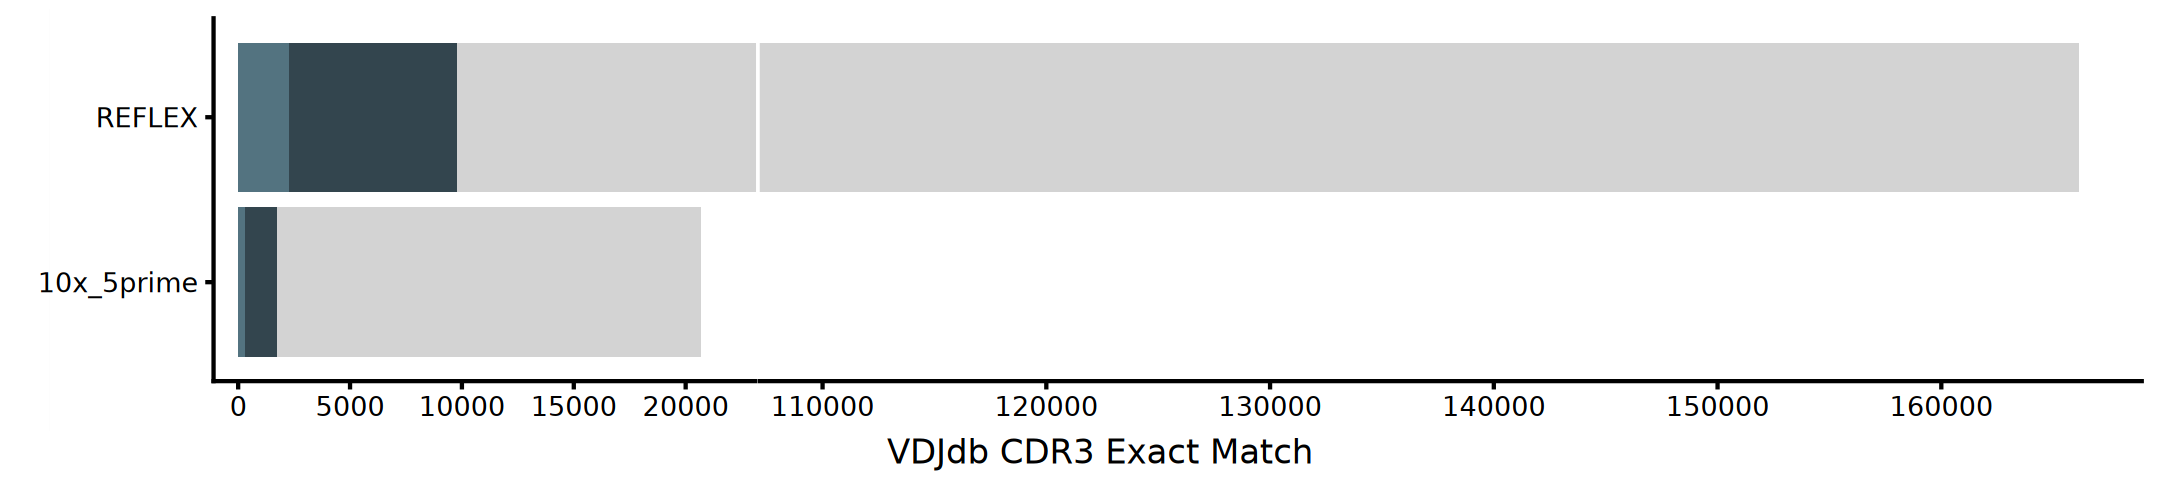

In [24]:
options(repr.plot.width = 18, repr.plot.height = 4)
ggplot(combined_df, aes(x=count, y=tech, fill=VDJdb_match)) + 
    geom_bar(stat='identity') + theme_classic(base_size=20) +
    # scale_x_continuous(breaks = c(0,5000,10000,125000,150000,175000)) +
    scale_fill_manual(values = c('lightgrey','#33454e','#537380')) + scale_x_break(c(22000,110000)) + 
    theme(legend.position = 'none') + ylab('') + xlab('VDJdb CDR3 Exact Match')

In [25]:
# Open the PDF graphics device
pdf("plots/Fig1d_vdjdb_match_plot.pdf", width = 18, height = 4) # You can specify width and height in inches

# Create your plot
ggplot(combined_df, aes(x=count, y=tech, fill=VDJdb_match)) + 
    geom_bar(stat='identity') + theme_classic(base_size=20) +
    # scale_x_continuous(breaks = c(0,5000,10000,125000,150000,175000)) +
    scale_fill_manual(values = c('lightgrey','#33454e','#537380')) + scale_x_break(c(22000,110000)) + 
    theme(legend.position = 'none') + ylab('') + xlab('VDJdb CDR3 Exact Match')

# Close the graphics device to save the plot
dev.off()

pdf 
  2

In [26]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/minimal/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] PNWColors_0.1.0    ggbreak_0.1.6      immunarch_0.9.1    patchwork_1.3.1   
 [5] data.table_1.17.8  dtplyr_1.3.1       cowplot_1.2.0      ggplot2_4.0.3     
 [9] dplyr_1.2.1        Seurat_5.3.0       SeuratObject_5.0.2 sp_2.2-0          

loaded via a namespace (and not attached):
  [1] RcppAnnoy_0.0.22       shiny